# exp-event-ontology-01 — 유전자별 변이 위치 ontology

## 목적
기존 08-spec LR의 gene mutation, A_pair, exact hotspot, 전역 count와 중복되지 않도록, 변이 문자열을 유전자별 위치 사건으로 구조화한다. 각 블록과 전체 결합이 실제로 OOF를 올리는지 seed 42의 동일 5-fold에서 확인한다.

### 신규 ontology 블록
- `locus`: gene × 정확 위치. 예: `IDH1__P132`
- `position_bin`: gene × 고정 50-aa 위치 구간. 예: `PIK3CA__BIN_501_550`
- `signature`: gene × 기능성 변이 유형 × 위치 구간. 예: `PIK3CA__MISSENSE__BIN_501_550`

각 token은 해당 outer fold의 train에서 3명 이상에게 발생한 경우만 채택한다. test는 읽지 않으며, position bin 폭 50·최소 support 3은 실행 전 고정한다.


In [1]:
from pathlib import Path
import subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt

def find_exp_model():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'exp_event_ontology_runner.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'exp_model' / 'common' / 'exp_event_ontology_runner.py'
        if direct.exists(): return path
        if project.exists(): return project.parent.parent
    raise FileNotFoundError('event-ontology runner를 찾지 못했습니다.')

EXP_MODEL = find_exp_model()
RUNNER = EXP_MODEL / 'common' / 'exp_event_ontology_runner.py'
RESULT_DIR = EXP_MODEL / 'result'
RUN_ID = 'exp-event-ontology-01'
SEED = 42
RUN_EXPERIMENT = True
print({'runner': RUNNER, 'seed': SEED, 'position_bin_width': 50, 'min_token_support': 3})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/common/exp_event_ontology_runner.py'), 'seed': 42, 'position_bin_width': 50, 'min_token_support': 3}


In [2]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--seed', str(SEED), '--run-id', RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    assert process.stdout is not None
    tail = []
    for line in process.stdout:
        print(line, end='')
        tail = (tail + [line])[-80:]
    return_code = process.wait()
    if return_code:
        raise RuntimeError(f'event-ontology runner failed (exit={return_code}). Last output:\n' + ''.join(tail))



row-local mutation cache: 100%|██████████| 4384/4384 [00:12<00:00, 363.70it/s]

event-ontology | seed 42:   0%|          | 0/5 [00:00<?, ?fold/s]
event-ontology | seed 42:  20%|██        | 1/5 [01:26<05:46, 86.72s/fold]
event-ontology | seed 42:  40%|████      | 2/5 [02:52<04:18, 86.17s/fold]
event-ontology | seed 42:  60%|██████    | 3/5 [04:12<02:46, 83.14s/fold]
event-ontology | seed 42:  80%|████████  | 4/5 [05:46<01:27, 87.65s/fold]
event-ontology | seed 42: 100%|██████████| 5/5 [07:10<00:00, 86.29s/fold]
event-ontology | seed 42: 100%|██████████| 5/5 [07:10<00:00, 86.10s/fold]
[
  {
    "experiment_id":"exp-event-ontology-01",
    "variant":"baseline",
    "seed":42,
    "oof_macro_f1":0.4825927952,
    "delta_vs_baseline":0.0,
    "feature_count_mean":8175.2,
    "runtime_seconds":430.533328292,
    "leakage_check":true,
    "nan_as_mutation_count":0,
    "position_bin_width":50,
    "min_token_support":3
  },
  {
    "experiment_id":"exp-event-ontology-01",
    "variant":"locu

,experiment_id,variant,seed,oof_macro_f1,delta_vs_baseline,feature_count_mean,runtime_seconds,leakage_check,nan_as_mutation_count,position_bin_width,min_token_support
3,exp-event-ontology-01,signature,42,0.486625,0.004032,35183.0,430.559915,True,0,50,3
1,exp-event-ontology-01,locus,42,0.485623,0.003030,10730.6,430.542461,True,0,50,3
2,exp-event-ontology-01,position_bin,42,0.483910,0.001317,40797.6,430.551347,True,0,50,3
0,exp-event-ontology-01,baseline,42,0.482593,0.000000,8175.2,430.533328,True,0,50,3
4,exp-event-ontology-01,all_ontology,42,0.481075,-0.001518,70360.8,430.568539,True,0,50,3


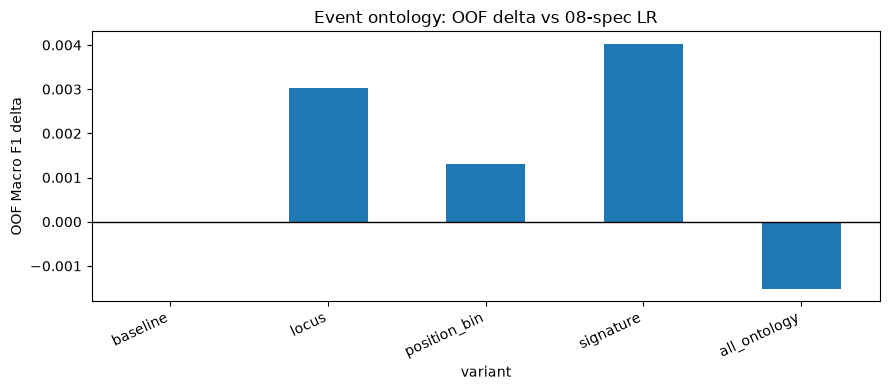

,variant,fold,fold_macro_f1,feature_count
0,all_ontology,3.0,0.481021,70360.8
1,baseline,3.0,0.481762,8175.2
2,locus,3.0,0.484441,10730.6
3,position_bin,3.0,0.483091,40797.6
4,signature,3.0,0.485887,35183.0


In [3]:
summary = pd.read_csv(RESULT_DIR / f'{RUN_ID}_seed{SEED}_summary.csv')
folds = pd.read_csv(RESULT_DIR / f'{RUN_ID}_seed{SEED}_folds.csv')
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary.sort_values('delta_vs_baseline', ascending=False))
ax = summary.plot.bar(x='variant', y='delta_vs_baseline', legend=False, figsize=(9, 4), title='Event ontology: OOF delta vs 08-spec LR')
ax.axhline(0, color='black', linewidth=1); ax.set_ylabel('OOF Macro F1 delta')
plt.xticks(rotation=25, ha='right'); plt.tight_layout()
plt.savefig(RESULT_DIR / f'{RUN_ID}_seed{SEED}_delta.png', dpi=160)
plt.show()
display(folds.groupby('variant', as_index=False).mean(numeric_only=True))
